In [13]:
import torch
import torch.nn.functional as F

image = torch.rand(1, 1, 6,6)
kernel = torch.ones(1, 1, 3, 3)
out = F.conv2d(image, kernel, stride=1, padding=0)
out2 = F.conv2d(image, kernel, stride=2, padding=0)
out3 = F.conv2d(image, kernel, stride=2, padding=1)
print(out.shape, out2.shape, out3.shape)

torch.Size([1, 1, 4, 4]) torch.Size([1, 1, 2, 2]) torch.Size([1, 1, 3, 3])


In [ ]:
import torch.nn as nn

conv_layer = nn.Conv2d(1, 3, 3, bias=False)
out_nn = conv_layer(image)  

# Get the learned kernels values.
weights = conv_layer.weight
out_f = F.conv2d(image, weights, bias=None)

difference = torch.abs(out_nn - out_f).sum()
print(f"Total Difference: {difference.item()}")

Parameter containing:
tensor([[[[ 0.1654, -0.1177,  0.0479],
          [ 0.0233, -0.1829,  0.2436],
          [ 0.2126,  0.3178,  0.0633]]],


        [[[-0.0397,  0.2352,  0.0106],
          [ 0.0229,  0.0962,  0.1397],
          [ 0.0280,  0.1496, -0.1669]]],


        [[[ 0.1133, -0.2688, -0.0458],
          [-0.2771,  0.2942,  0.2440],
          [ 0.2384, -0.0102,  0.3038]]]], requires_grad=True)
Total Difference: 0.0
tensor([[[[ 3.7635e-01,  5.2099e-01,  5.8774e-01,  3.6327e-01],
          [ 8.1040e-01,  5.5587e-01,  4.2040e-01,  3.1555e-01],
          [ 4.8562e-01,  3.0262e-01,  3.0633e-01,  2.0676e-01],
          [ 4.6397e-01,  2.8816e-01,  3.2215e-01,  2.2635e-01]],

         [[ 1.1834e-01,  1.8006e-01,  2.9109e-01,  3.5733e-01],
          [ 2.0357e-01,  4.0601e-01,  4.2294e-01,  2.3375e-01],
          [ 9.8527e-02,  5.0871e-01,  3.7570e-01,  1.4470e-01],
          [ 1.8886e-01,  3.9931e-01,  2.2676e-01, -5.6863e-04]],

         [[ 4.2868e-01,  6.2831e-01,  5.2770e-01,  1.6959e

Starting Training...


/home/mca/anaconda3/lib/python3.11/site-packages/torch/autograd/graph.py:865: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [1/5], Loss: 0.0663
Epoch [2/5], Loss: 0.0145
Epoch [3/5], Loss: 0.0467
Epoch [4/5], Loss: 0.0699
Epoch [5/5], Loss: 0.0448

Total Learnable Parameters: 149798


<Figure size 1000x800 with 0 Axes>

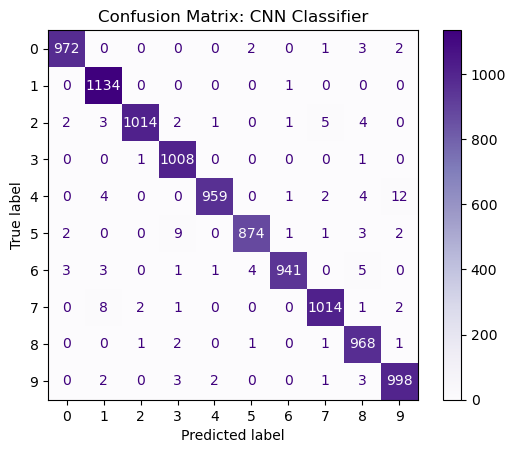

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Configuration
batch_size = 100
learning_rate = 0.001
num_epochs = 5

# 2. Model Definition 
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__() # Fixed syntax
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d((2, 2), stride=2),
            nn.Conv2d(64, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d((2,2), 3),
            nn.Conv2d(128, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d((2,2), stride=2)
        )
        self.classification_head = nn.Sequential(
            nn.Linear(64, 20, bias=True),
            nn.ReLU(),
            nn.Linear(20, 10, bias=True)
        )
    
    def forward(self, x):
        features = self.net(x)
        return self.classification_head(features.view(x.size(0), -1))

# 3. Data Loading
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# 4. Training
model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Starting Training...")
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# 5. Parameter Verification
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal Learnable Parameters: {total_params}')

# 6. Evaluation & Confusion Matrix
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# Display Results
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap='Purples', values_format='d')
plt.title("Confusion Matrix: CNN Classifier")
plt.show()


Scale      | Params     | Drop %     | Accuracy %
--------------------------------------------------
1.0        | 149798     | 0.00       | 98.01     
0.75       | 84463      | 43.62      | 98.65     


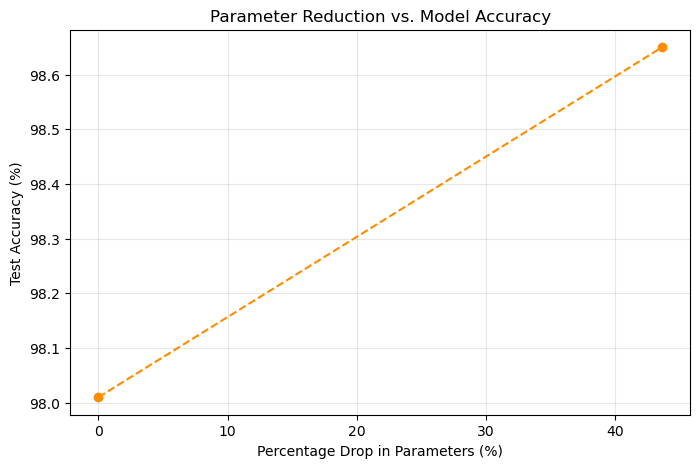

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. Flexible Model Definition
class ParametricCNN(nn.Module):
    def __init__(self, scale=1.0):
        super().__init__()
        # Scaling channels and linear units to reduce parameters
        c1, c2, c3 = int(64*scale), int(128*scale), int(64*scale)
        l1 = int(20*scale)
        
        self.net = nn.Sequential(
            nn.Conv2d(1, c1, 3), nn.ReLU(),
            nn.MaxPool2d((2, 2), stride=2),
            nn.Conv2d(c1, c2, 3), nn.ReLU(),
            nn.MaxPool2d((2, 2), stride=3),
            nn.Conv2d(c2, c3, 3), nn.ReLU(),
            nn.MaxPool2d((2, 2), stride=2)
        )
        self.classification_head = nn.Sequential(
            nn.Linear(c3, l1), nn.ReLU(),
            nn.Linear(l1, 10)
        )
    
    def forward(self, x):
        features = self.net(x)
        return self.classification_head(features.view(x.size(0), -1))

# 2. Setup Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

def get_accuracy_and_params(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    return total_params, 100 * correct / len(test_set)

# 3. Experiment Loop
scales = [1.0, 0.75] # Reduction factors
results = []

print(f"{'Scale':<10} | {'Params':<10} | {'Drop %':<10} | {'Accuracy %':<10}")
print("-" * 50)

base_params = 0

for i, s in enumerate(scales):
    model = ParametricCNN(scale=s)
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.CrossEntropyLoss()
    
    # Quick Training (2 Epochs for demonstration)
    model.train()
    for epoch in range(2):
        for imgs, lbls in train_loader:
            optimizer.zero_grad()
            criterion(model(imgs), lbls).backward()
            optimizer.step()
            
    p_count, acc = get_accuracy_and_params(model)
    if i == 0: base_params = p_count
    
    p_drop = 100 * (1 - p_count / base_params)
    results.append((p_drop, acc))
    print(f"{s:<10} | {p_count:<10} | {p_drop:<10.2f} | {acc:<10.2f}")

# 4. Plotting
drops, accs = zip(*results)
plt.figure(figsize=(8, 5))
plt.plot(drops, accs, marker='o', linestyle='--', color='darkorange')
plt.title("Parameter Reduction vs. Model Accuracy")
plt.xlabel("Percentage Drop in Parameters (%)")
plt.ylabel("Test Accuracy (%)")
plt.grid(True, alpha=0.3)
plt.show()
